<a href="https://colab.research.google.com/github/Anyajain05/Machine-learning/blob/main/Copy_of_Linear_Regression_Mustafa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np

class MyLinearRegression:
    def __init__(self, weight=3, bias=4, learning_rate=0.005,
                 iterations=800):
        self.weight = weight
        self.bias = bias
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.cost_trend = []
        self.cost = 0

    def predict(self, x):
        predicted_set = []
        for i in range(len(x)):
            # Ensure x[i] is treated as a scalar
            x_val = x[i].item() if isinstance(x[i], np.ndarray) else x[i]
            predicted_value = self.weight * x_val + self.bias
            predicted_set.append(predicted_value)
        return predicted_set

    def cost_function(self, x, y):
        count = len(x)
        total_error = 0.0
        for i in range(count):
            # Ensure x[i] is treated as a scalar
            x_val = x[i].item() if isinstance(x[i], np.ndarray) else x[i]
            total_error += (y[i] - (self.weight * x_val +
                            self.bias)) ** 2
        # Use .item() to extract scalar from total_error if it became an array
        return total_error.item() / (2 * count) if isinstance(total_error, np.ndarray) else total_error / (2 * count)

    def update_weights(self, x, y):
        weight_deriv = 0.0 # Initialize as float to ensure it stays scalar
        bias_deriv = 0.0   # Initialize as float to ensure it stays scalar
        count = len(x)

        for i in range(count):
            # Ensure x[i] is treated as a scalar
            x_val = x[i].item() if isinstance(x[i], np.ndarray) else x[i]
            # Calculate partial derivatives
            # Ensure self.weight and self.bias are treated as scalars
            error_term = y[i] - (self.weight * x_val + self.bias)

            weight_deriv += -2 * x_val * error_term
            bias_deriv += -2 * error_term

        # We subtract because the derivatives point in direction of steepest ascent
        self.weight -= (weight_deriv / count) * self.learning_rate
        self.bias -= (bias_deriv / count) * self.learning_rate

    def train(self, x, y):
        for i in range(self.iterations):
            self.update_weights(x, y)
            # Calculating cost
            self.cost = self.cost_function(x, y)
            self.cost_trend.append(self.cost)
           # if i % 10000 == 0:
            print("Iteration: {}\t Weight: {}\t Bias: {}\t Cost: {}".format(i, self.weight, self.bias, self.cost))


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# intialise data of lists.
data = {'Hours':[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8],
        'Scores':[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]}

# Create DataFrame
studentscores = pd.DataFrame(data)

# Print the output.
studentscores

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30
5,1.5,20
6,9.2,88
7,5.5,60
8,8.3,81
9,2.7,25


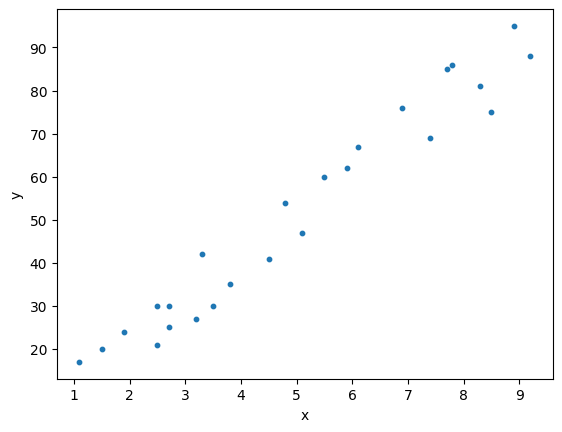

In [18]:
x=[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8]
y=[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]
plt.scatter(x,y,s=10)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [19]:
#from my_linear_regression import MyLinearRegression
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# Importing the dataset

X = studentscores.iloc[:, :-1].values
y = studentscores.iloc[:, -1].values
X,y

(array([[2.5],
        [5.1],
        [3.2],
        [8.5],
        [3.5],
        [1.5],
        [9.2],
        [5.5],
        [8.3],
        [2.7],
        [7.7],
        [5.9],
        [4.5],
        [3.3],
        [1.1],
        [8.9],
        [2.5],
        [1.9],
        [6.1],
        [7.4],
        [2.7],
        [4.8],
        [3.8],
        [6.9],
        [7.8]]),
 array([21, 47, 27, 75, 30, 20, 88, 60, 81, 25, 85, 62, 41, 42, 17, 95, 30,
        24, 67, 69, 30, 54, 35, 76, 86]))

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0)

# Fitting Simple Linear Regression to the Training set
regressor = MyLinearRegression()
regressor.train(X_train, y_train)
print('Weight: ' + str(regressor.weight) + ' Bias: ' + str(regressor.bias))

# Predicting the Test set results
y_pred = regressor.predict(X_test)


/tmp/ipykernel_4962/1857607967.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(total_error) / (2 * count)


Iteration: 0	 Weight: [5.2053375]	 Bias: [4.338]	 Cost: 317.3173901646991
Iteration: 1	 Weight: [6.63997084]	 Bias: [4.55628845]	 Cost: 143.54261063045053
Iteration: 2	 Weight: [7.57332358]	 Bias: [4.6967171]	 Cost: 70.02704869314583
Iteration: 3	 Weight: [8.18063375]	 Bias: [4.78650711]	 Cost: 38.92556209972674
Iteration: 4	 Weight: [8.5758794]	 Bias: [4.84336361]	 Cost: 25.76710430877517
Iteration: 5	 Weight: [8.83319394]	 Bias: [4.87880233]	 Cost: 20.199343283213846
Iteration: 6	 Weight: [9.00079512]	 Bias: [4.90031333]	 Cost: 17.84278595000686
Iteration: 7	 Weight: [9.11004465]	 Bias: [4.91276826]	 Cost: 16.844713559648
Iteration: 8	 Weight: [9.18134075]	 Bias: [4.91933572]	 Cost: 16.421344348990743
Iteration: 9	 Weight: [9.22795083]	 Bias: [4.92207664]	 Cost: 16.24110404736078
Iteration: 10	 Weight: [9.25850422]	 Bias: [4.92233146]	 Cost: 16.163722098793293
Iteration: 11	 Weight: [9.27861363]	 Bias: [4.92097205]	 Cost: 16.12985785645784
Iteration: 12	 Weight: [9.29192964]	 Bias: [

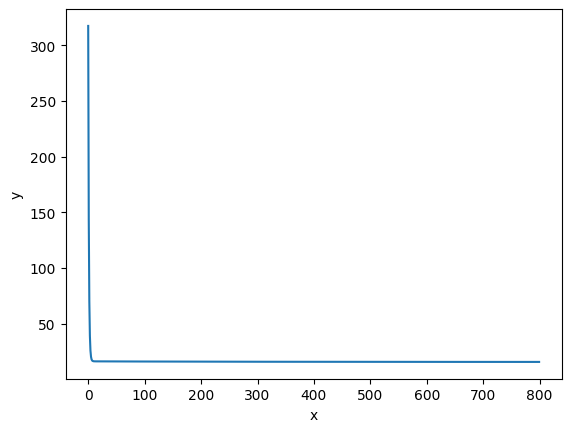

In [20]:
x = [int(i) for i in range(len(regressor.cost_trend))]
y = regressor.cost_trend
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

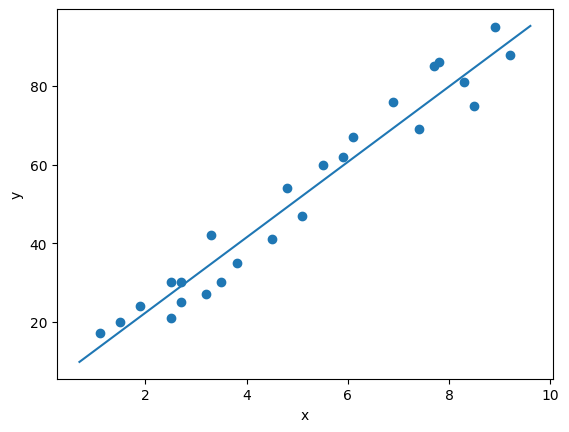

In [21]:
w = regressor.weight
b = regressor.bias
x=[2.5,5.1,3.2,8.5,3.5,1.5,9.2,5.5,8.3,2.7,7.7,5.9,4.5,3.3,1.1,8.9,2.5,1.9,6.1,7.4,2.7,4.8,3.8,6.9,7.8]
y=[21,47,27,75,30,20,88,60,81,25,85,62,41,42,17,95,30,24,67,69,30,54,35,76,86]
plt.scatter(x,y)
axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = b + w * x_vals
plt.plot(x_vals, y_vals)
plt.xlabel('x')
plt.ylabel('y')
plt.show()